# Fashion Demand Forecasting

## Business Problem

Fashion retail demand is highly seasonal and volatile. 
Inaccurate forecasts lead to stockouts for high-demand items and overstock for slow-moving products, directly impacting revenue and inventory costs.

This project evaluates forecasting models to support inventory allocation and seasonal assortment planning across product categories.

The core decision addressed:
**How much inventory should be allocated to each product category for upcoming seasonal periods?**

This analysis is designed to support merchandising and inventory planning teams responsible for seasonal buy decisions.

---

## Data Description

**Dataset:** H&M Personalized Fashion Recommendations (Kaggle)  
**Scale:** 30M+ transactions  

**Key Tables:**
- Transactions (customer, article, date, price)
- Articles (category, garment type)
- Customers (demographics)

The dataset enables aggregation of monthly unit demand at the product-category level to analyze seasonality, trends, and peak behavior.

---

## Forecasting Objective

The objective is to forecast monthly unit demand per product category 
for the next 3–6 months to support short-term seasonal inventory planning.

Performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Multiple modeling approaches are compared:
- Naive baselines
- Seasonal Naive
- Moving Average
- Ridge Regression
- Random Forest
- SARIMA

The goal is not only predictive accuracy, but determining whether increased model complexity yields meaningful operational benefit.

---

## Analytical Approach

The project follows a structured modeling progression:

1. Exploratory data analysis to identify seasonal patterns  
2. Implementation of simple baseline models  
3. Linear machine learning modeling (Ridge)  
4. Nonlinear modeling (Random Forest)  
5. Classical time-series modeling (SARIMA)  
6. Model comparison and deployment recommendation  

This structured comparison allows evaluation of model sophistication versus business value.

# Exploratory Data Analysis

I perform an exploratory analysis and of the H&M dataset to understand overall sales trends, identify key product categories, and detect seasonal demand patterns. These insights will guide the forecasting models in later stages.

## Data Loading & Initial Exploration
  
It contains three main files:

- **`transactions_train.csv`**  
  Each row = a single purchase.  
  - `t_dat`: date of transaction (purchase date)  
  - `customer_id`: anonymized customer identifier  
  - `article_id`: purchased product ID  
  - `price`: purchase price  
  - `sales_channel_id`: sales channel (1 = online, 2 = store)  

- **`articles.csv`**  
  Metadata about each product (joined using `article_id`).  
  Includes:  
  - `prod_name`: product name  
  - `product_type_name`: e.g., “T-shirt,” “Vest top”  
  - `product_group_name`: higher-level grouping (e.g., “Garment Upper body”)  
  - `garment_group_name`: another category level  
  - `detail_desc`: product description  
  - … plus attributes like color, department, index, etc.  

- **`customers.csv`**  
  Metadata about each customer (joined using `customer_id`).  
  Includes:  
  - `club_member_status`: loyalty program activity  
  - `fashion_news_frequency`: how often they receive H&M news  
  - `age`: customer’s age  
  - `postal_code`: anonymized region identifier  

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

#Load Dataset
transactions = pd.read_csv("transactions_train.csv")
articles = pd.read_csv("articles.csv")
customers = pd.read_csv("customers.csv")

#Quick look
print(transactions.head())
print(articles.head())
print(customers.head())

        t_dat                                        customer_id  article_id  \
0  2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   663713001   
1  2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   541518023   
2  2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   505221004   
3  2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   685687003   
4  2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   685687004   

      price  sales_channel_id  
0  0.050831                 2  
1  0.030492                 2  
2  0.015237                 2  
3  0.016932                 2  
4  0.016932                 2  
   article_id  product_code          prod_name  product_type_no  \
0   108775015        108775          Strap top              253   
1   108775044        108775          Strap top              253   
2   108775051        108775      Strap top (1)              253   
3   110065001        110065  OP T-shirt (Idro)             

### First look

I loaded the datasets and displayed the first five rows of each file using `.head()`. This confirms that:

- The **transactions** dataset is very large and contains the purchase history.  
- The **articles** dataset enriches transactions with product information (categories, garment type, etc.).  
- The **customers** dataset provides demographics and membership info.  

This gives us three connected tables:

- **transactions (facts)** → purchases over time  
- **articles (dimension)** → product attributes  
- **customers (dimension)** → customer attributes  

---

## Exploratory Analysis
- Plot sales trends
- Identify top brands
- Look for seasonal effects

## Sales Trends Over Time

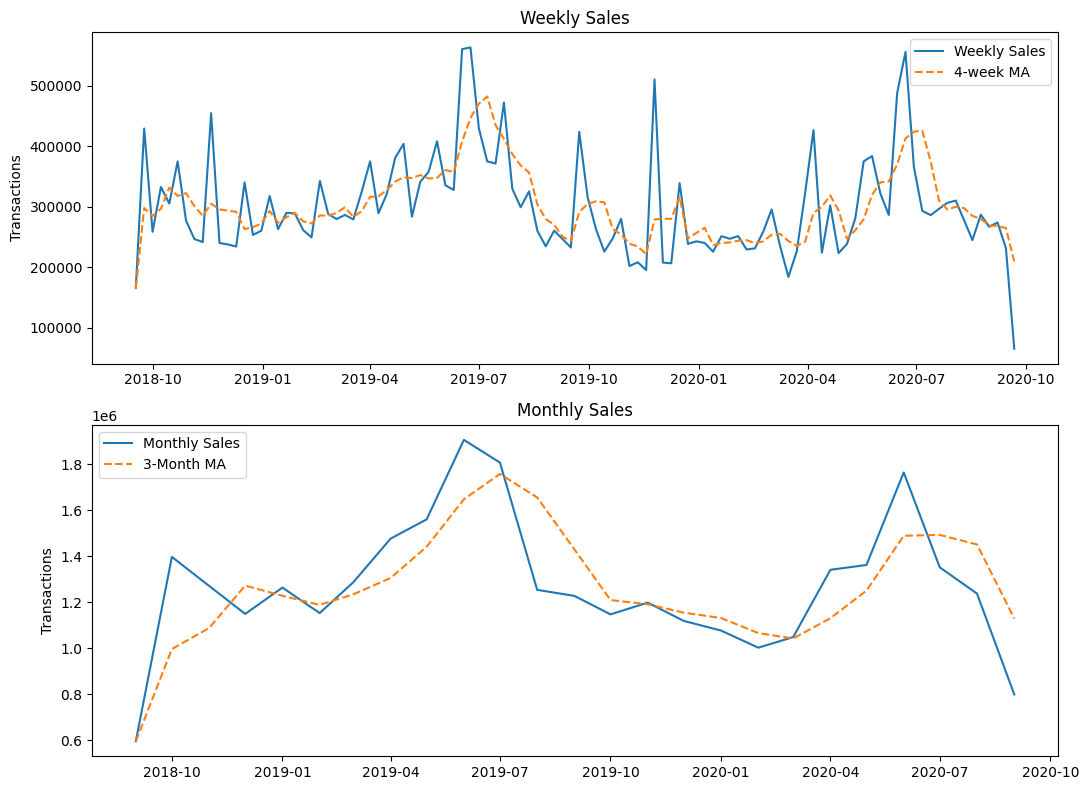

In [2]:
# --- Explore Sale Trends Over Time ---

import pandas as pd
import matplotlib.pyplot as plt


#1. Convert transaction date to datetime:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')
transactions = transactions.dropna(subset=['t_dat'])

#2. Aggregate by week/month (counts of transactions):
weekly_sales = transactions.groupby(transactions['t_dat'].dt.to_period('W')).size()
monthly_sales = transactions.groupby(transactions['t_dat'].dt.to_period('M')).size()

# Convert Period Index -> Timestamp for plotting
weekly_sales.index = weekly_sales.index.to_timestamp()
monthly_sales.index = monthly_sales.index.to_timestamp()

#3. Add rolling averages for readability
#   - Weekly: 4-week moving average
#   - Monthly: 3-month moving average
weekly_ma = weekly_sales.rolling(window=4, min_periods=1).mean()
monthly_ma = monthly_sales.rolling(window=3, min_periods=1).mean()

#4. Plot in separate subplots
fig, ax = plt.subplots( 2, 1, figsize=(11, 8), sharex = False )

# Weekly Chart
ax[0].plot(weekly_sales.index, weekly_sales.values, label='Weekly Sales')
ax[0].plot(weekly_ma.index, weekly_ma.values, linestyle='--', label='4-week MA')
ax[0].set_title('Weekly Sales')
ax[0].set_ylabel('Transactions')
ax[0].legend()

# Monthly Chart
ax[1].plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales')
ax[1].plot(monthly_ma.index, monthly_ma.values, linestyle='--', label='3-Month MA')
ax[1].set_title('Monthly Sales')
ax[1].set_ylabel('Transactions')
ax[1].legend()

plt.tight_layout()
plt.show()

The weekly sales plot (top) shows raw transaction counts (**blue**) alongside a 4-week moving average (**orange dashed line**). Weekly sales are noisy, with frequent ups and downs, but the moving average highlights the underlying short-term trend.

The monthly sales plot (bottom) is smoother, showing total transactions per month with a 3-month moving average. This reveals longer-term patterns, including a peak of ~1.9M transactions around June 2019 and a decline to ~1.0M transactions by September 2019.

### Insights
Weekly sales are useful for detecting short-term fluctuations (e.g., promotions or marketing events), while monthly sales are more reliable for identifying long-term demand trends. These patterns confirm that demand forecasting should account for both short-term volatility and long-term seasonality. For a retailer like H&M, this means planning inventory and promotions around predictable seasonal peaks.


## Explore Top Categories & Garment Groups

product_group_name
Garment Upper body    12552755
Garment Lower body     7046054
Garment Full body      3552470
Swimwear               2579222
Underwear              2565858
Accessories            1599593
Shoes                   745521
Socks & Tights          685712
Nightwear               348180
Unknown                  97040
Name: count, dtype: int64


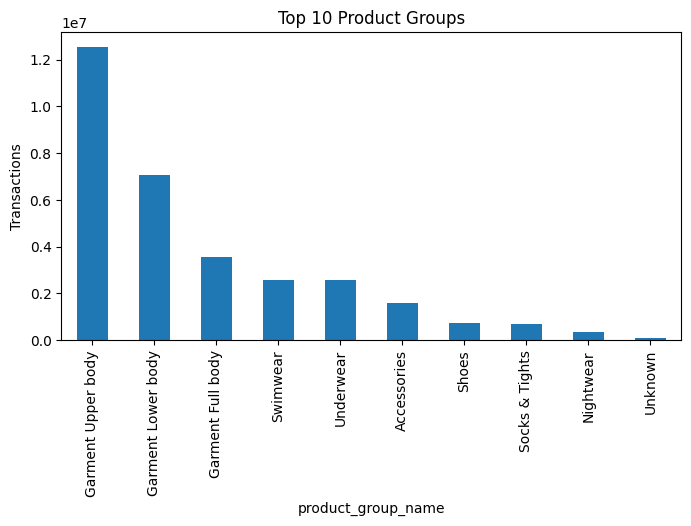

garment_group_name
Jersey Fancy         5171611
Jersey Basic         3268451
Under-, Nightwear    2966788
Trousers             2953711
Swimwear             2538085
Blouses              2510441
Knitwear             2392807
Dresses Ladies       2147529
Accessories          1645464
Trousers Denim       1279886
Name: count, dtype: int64


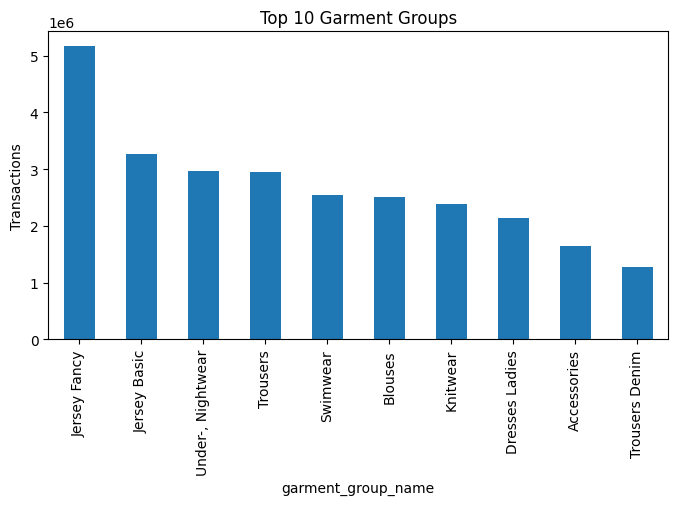

In [3]:
transactions = pd.read_csv("transactions_train.csv")
articles = pd.read_csv("articles.csv")

df = transactions.merge(articles, on = 'article_id', how = 'left')

# Top categories
top_categories = df['product_group_name'].value_counts().head(10)
print(top_categories)

top_categories.plot(kind="bar", figsize=(8,4), title='Top 10 Product Groups')
plt.ylabel("Transactions")
plt.show()

# Top garment types
top_garments = df['garment_group_name'].value_counts().head(10)
print(top_garments)

top_garments.plot(kind="bar", figsize=(8,4), title="Top 10 Garment Groups")
plt.ylabel("Transactions")
plt.show()


To understand which product types drive the most sales, I aggregated transactions by product and garment categories.

- At the **product group level**, the largest segments are:
  - Garment Upper body (~12.5M transactions)
  - Garment Lower body (~7.0M)
  - Garment Full body (~3.5M)
  - Swimwear and Underwear also appear in the top 5.

- At the **garment group level**, the most common items include:
  - Jersey Fancy (~51M) and Jersey Basic (~32M), which together dominate H&M’s product mix.
  - Under-/Nightwear (~29M), Trousers (~29M), and Swimwear (~25M) are also significant.

### Insights
These results confirm that H&M’s core business relies heavily on **everyday basics** (jersey and knitwear) while seasonal products like **swimwear** also make up a large share. These categories will be strong candidates for focused forecasting, as they combine volume with clear seasonal patterns.


## Explore Seasonality in Sales

In [4]:
print(df['product_group_name'].unique())


['Underwear' 'Garment Upper body' 'Garment Lower body' 'Accessories'
 'Socks & Tights' 'Shoes' 'Garment Full body' 'Nightwear' 'Swimwear'
 'Underwear/nightwear' 'Cosmetic' 'Unknown' 'Items' 'Bags'
 'Interior textile' 'Furniture' 'Garment and Shoe care' 'Stationery' 'Fun']


<Axes: title={'center': 'Seasonal Categories — Monthly Sales'}, xlabel='t_dat', ylabel='Units Sold'>

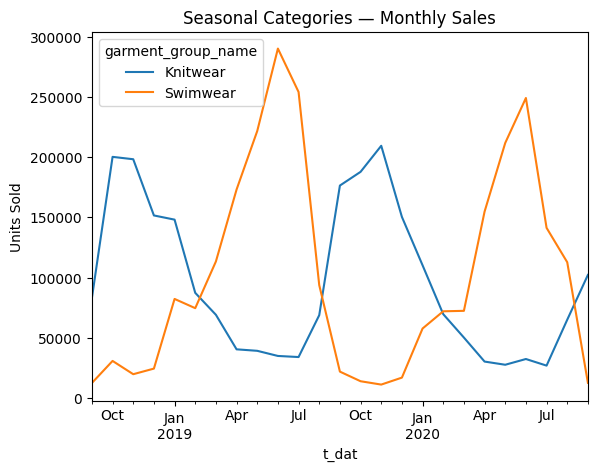

In [6]:
df["t_dat"] = pd.to_datetime(df["t_dat"])

categories = ["Swimwear", "Knitwear"]  # adjust based on value_counts
subset = df[df["garment_group_name"].isin(categories)]
monthly = (
    subset.groupby([subset["t_dat"].dt.to_period("M"), "garment_group_name"])
    .size()
    .unstack(fill_value=0)
)
monthly.index = monthly.index.to_timestamp()
monthly.plot(title="Seasonal Categories — Monthly Sales", ylabel="Units Sold")


Most seasonal categories:
 garment_group_name
Shorts                  1.171527
Swimwear                0.863363
Knitwear                0.657760
Dresses/Skirts girls    0.652082
Dresses Ladies          0.497956
dtype: float64


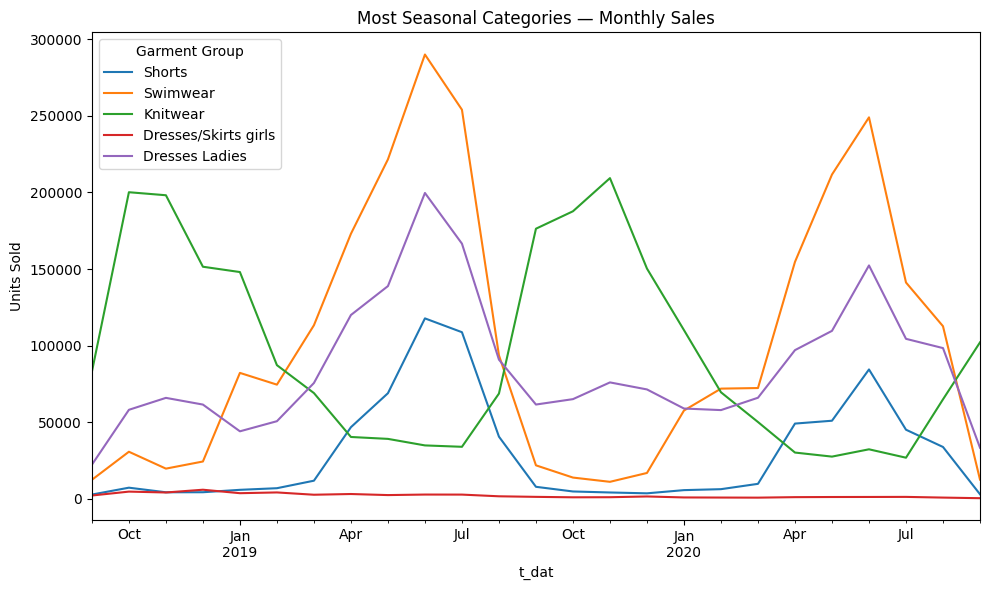

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime is parsed
df["t_dat"] = pd.to_datetime(df["t_dat"], errors="coerce")
df = df.dropna(subset=["t_dat"])

# Aggregate monthly sales per garment group
monthly_cat = (
    df.groupby([df["t_dat"].dt.to_period("M"), "garment_group_name"])
      .size()
      .unstack(fill_value=0)
)

# Compute coefficient of variation (CV = std / mean) for each category
cv = monthly_cat.std() / monthly_cat.mean()

# Top 5 most seasonal categories
top_seasonal = cv.sort_values(ascending=False).head(5)
print("Most seasonal categories:\n", top_seasonal)

# Plot them together
monthly_top = monthly_cat[top_seasonal.index]
monthly_top.index = monthly_top.index.to_timestamp()

ax = monthly_top.plot(title="Most Seasonal Categories — Monthly Sales", figsize=(10,6))
ax.set_ylabel("Units Sold")
ax.legend(title="Garment Group")
plt.tight_layout()
plt.show()



To check for seasonality, I compared **Swimwear** and **Knitwear** sales over time.  
- **Swimwear** peaks during the summer months (June–July), reaching ~300K monthly transactions.  
- **Knitwear** rises sharply in winter (December–January), doubling from ~80K in summer to ~200K in winter.  

This confirms that certain product categories follow strong seasonal demand patterns.

To extend this analysis, I computed the **coefficient of variation (CV)** for each garment group. The top 5 most seasonal categories were:  
1. Shorts (CV = 1.17)  
2. Swimwear (0.86)  
3. Knitwear (0.65)  
4. Dresses/Skirts (Girls) (0.65)  
5. Dresses Ladies (0.50)  

These categories fluctuate heavily month-to-month, making them both challenging and interesting for forecasting.

### Key Insights
- Sales trends show stable growth with seasonal peaks.
- Top categories (Upper Body, Jersey) dominate overall volume.
- Seasonal products (Swimwear, Shorts, Knitwear) fluctuate sharply.
- Algorithmic check confirms seasonal demand patterns beyond intuition.  

# Feature Engineering & Baseline Models 

In this section, I build on exploratory analysis by:
- Cleaning and preparing the dataset for modeling  
- Engineering time-based and demand-related features (lags, rolling averages, seasonality indicators)  
- Conducting deeper exploratory checks for trends, anomalies, and seasonality  
- Establishing baseline forecasting models (Naive and Moving Average) and a simple regression benchmark  

These steps set the foundation for more advanced machine learning and time-series models.


## Data Loading and Preparation

Load transaction and article data, merge key attributes, and build monthly-level demand time series for selected product categories.


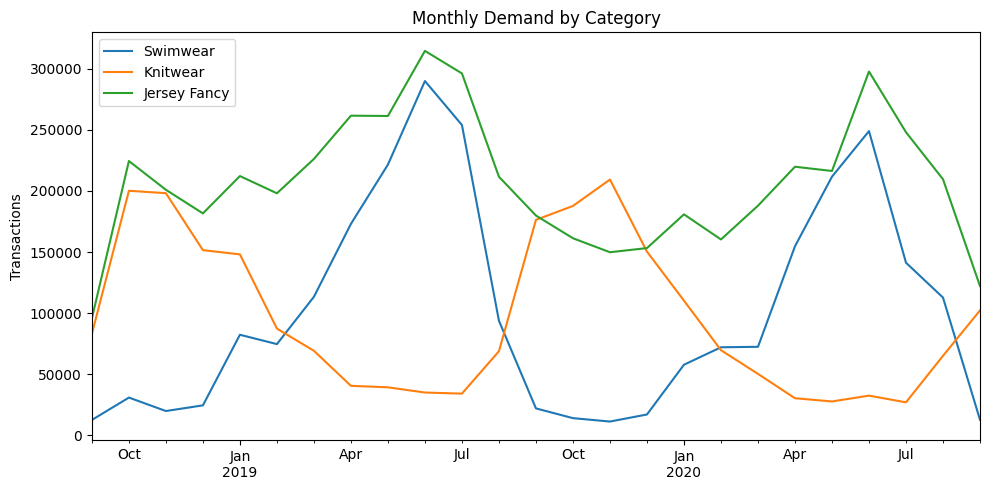

In [8]:
# --- 2. Data Loading and Preparation ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths: adjust if your CSVs are in a subfolder (e.g., "data/transactions_train.csv")
transactions = pd.read_csv(
    "transactions_train.csv",
    usecols=["t_dat", "article_id", "price", "sales_channel_id"]
)
articles = pd.read_csv(
    "articles.csv",
    usecols=["article_id", "garment_group_name", "product_group_name"]
)

# Merge + datetime parse
df = transactions.merge(articles, on="article_id", how="left")
df["t_dat"] = pd.to_datetime(df["t_dat"], errors="coerce")
df = df.dropna(subset=["t_dat"])

# Helper to create a continuous monthly time series for a garment group
def monthly_series(df, garment_group_name: str) -> pd.Series:
    sub = df[df["garment_group_name"] == garment_group_name]
    ts = sub.groupby(sub["t_dat"].dt.to_period("M")).size().astype("float")
    if ts.empty:
        raise ValueError(f"No rows found for garment_group_name='{garment_group_name}'. "
                         f"Check spelling/casing with df['garment_group_name'].value_counts().head(20)")
    ts = ts.sort_index()
    full_idx = pd.period_range(ts.index.min(), ts.index.max(), freq="M")
    ts = ts.reindex(full_idx, fill_value=0)
    ts.index = ts.index.to_timestamp()
    return ts

# Choose three categories (seasonal + winter + stable/high-volume)
target_groups = ["Swimwear", "Knitwear", "Jersey Fancy"]  # adjust if needed

series_dict = {g: monthly_series(df, g) for g in target_groups}

# Quick sanity plot
ax = pd.DataFrame(series_dict).plot(title="Monthly Demand by Category", figsize=(10,5))
ax.set_ylabel("Transactions")
plt.tight_layout(); plt.show()

### Demand Pattern Interpretation

The monthly time-series plot highlights distinct seasonal and structural differences across product categories:

- **Swimwear** exhibits strong mid-year peaks, reflecting clear summer seasonality and high demand concentration during specific months.
- **Knitwear** demonstrates inverse seasonality, with demand increasing during colder months and declining in warmer periods.
- **Jersey Fancy** shows relatively higher and more stable volume across months, suggesting it behaves more like a core/basic category with moderate seasonal fluctuations.

These contrasting demand dynamics reinforce the importance of modeling temporal dependencies explicitly. Categories with strong seasonality require models that capture recurring patterns, while more stable categories may rely more heavily on recent demand trends.

The next step is to transform these time-series into supervised learning datasets using lag features, rolling averages, and seasonal indicators to enable quantitative forecasting evaluation.

## Feature Engineering

Create time-based and demand-related features to help forecasting models learn from temporal patterns:
- Lag features (previous 1, 3, 6, 12 months)
- Rolling averages
- Month/season indicators


In [9]:
# --- 3. Feature Engineering (helper functions) ---

def make_supervised(ts: pd.Series, add_rolling=True) -> pd.DataFrame:
    """
    Turn a monthly time series into a supervised dataframe with lag features and month dummies.
    """
    dfX = pd.DataFrame({"y": ts})
    for L in [1, 3, 6, 12]:
        dfX[f"lag_{L}"] = dfX["y"].shift(L)

    if add_rolling:
        dfX["roll3"]  = dfX["y"].rolling(3).mean().shift(1)
        dfX["roll6"]  = dfX["y"].rolling(6).mean().shift(1)
        dfX["roll12"] = dfX["y"].rolling(12).mean().shift(1)

    dfX["month"] = dfX.index.month
    dfX = pd.get_dummies(dfX, columns=["month"], drop_first=True)  # month_2..month_12
    return dfX.dropna()

# Example preview on one series
make_supervised(series_dict[target_groups[0]]).head()

,y,lag_1,lag_3,lag_6,lag_12,roll3,roll6,roll12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
2019-09-01,21942.0,93718.0,289983.0,113344.0,12502.0,212556.666667,190936.666667,115835.333333,False,False,False,False,False,False,False,True,False,False,False
2019-10-01,13962.0,21942.0,253969.0,173031.0,30811.0,123209.666667,175703.000000,116622.000000,False,False,False,False,False,False,False,False,True,False,False
2019-11-01,11188.0,13962.0,93718.0,221575.0,19796.0,43207.333333,149191.500000,115217.916667,False,False,False,False,False,False,False,False,False,True,False
2019-12-01,16965.0,11188.0,21942.0,289983.0,24448.0,15697.333333,114127.000000,114500.583333,False,False,False,False,False,False,False,False,False,False,True
2020-01-01,57705.0,16965.0,13962.0,253969.0,82257.0,14038.333333,68624.000000,113877.000000,False,False,False,False,False,False,False,False,False,False,False


### Feature Engineering Strategy

To transform the monthly demand time series into a supervised learning format, I engineer temporal features that capture historical dependency and seasonality.

The following feature groups are created:

- **Lag Features (1, 3, 6, 12 months):** Capture short-term momentum and yearly seasonality effects.
- **Rolling Averages (3, 6, 12 months):** Smooth recent demand trends to reduce noise and highlight underlying patterns.
- **Month Dummies:** Encode recurring seasonal structure explicitly.

All rolling features are shifted by one period to prevent data leakage, ensuring that only past information is used when predicting future demand.

This transformation allows regression-based models to learn structured temporal relationships in demand behavior.

## Train–Validation Split

To evaluate model performance, I split the time series into:
- **Training:** September 2018 – March 2020  
- **Validation:** April 2020 – September 2020  

This 6-month validation window simulates an out-of-sample forecast.


In [10]:
# --- 4. Train–Validation Split ---

VAL_START = "2020-04-01"   # first validation month
VAL_END   = "2020-09-01"   # last validation month

def split_tv(ts: pd.Series, val_start: str, val_end: str):
    train = ts[ts.index < val_start]
    valid = ts[(ts.index >= val_start) & (ts.index <= val_end)]
    return train, valid

splits = {g: split_tv(ts, VAL_START, VAL_END) for g, ts in series_dict.items()}

# Sanity check sizes
{g: (len(tr), len(va)) for g, (tr, va) in splits.items()}

{'Swimwear': (19, 6), 'Knitwear': (19, 6), 'Jersey Fancy': (19, 6)}

### Time-Based Train–Validation Split

To evaluate forecasting performance realistically, I split each category’s time series into a chronological training and validation window.

- **Training Period:** September 2018 – March 2020  
- **Validation Period:** April 2020 – September 2020  

This time-based split ensures that the model is trained only on historical data and evaluated on future periods, preventing information leakage.

The 6-month validation window simulates an out-of-sample forecasting scenario, reflecting how demand models would be used in practice for forward-looking inventory planning decisions.

## Baseline Forecasting Models

To evaluate model performance meaningfully, I first establish simple baseline forecasting models.  
These baselines provide reference points to determine whether more advanced models add predictive value.

The following baseline approaches are implemented:

- **Naive Forecast**: Uses the most recent observed value as the prediction for all future periods.
- **Seasonal Naive Forecast**: Uses the value from the same month in the previous year (12-month lag), capturing recurring seasonal patterns.
- **Moving Average Forecast**: Uses the average of the most recent rolling window (e.g., 3 months) to smooth short-term fluctuations.

These baseline models represent progressively more informed assumptions about demand behavior — from simple persistence to basic seasonality and smoothing.

If a more complex model cannot outperform these baselines, it does not justify additional complexity.

In [11]:
# --- 5. Baseline Models ---

def naive_forecast(train: pd.Series, valid: pd.Series) -> pd.Series:
    return pd.Series(train.iloc[-1], index=valid.index)

def seasonal_naive_forecast(train: pd.Series, valid: pd.Series, season: int = 12) -> pd.Series:
    fcst = []
    for dt in valid.index:
        idx = dt - pd.DateOffset(months=season)
        fcst.append(train.get(idx, train.iloc[-1]))  # fallback if season index missing
    return pd.Series(fcst, index=valid.index)

def moving_average_forecast(train: pd.Series, valid: pd.Series, window: int = 3) -> pd.Series:
    val = train.rolling(window).mean().iloc[-1]
    return pd.Series(val, index=valid.index)

## Regression Benchmark Model (Ridge Regression)

To benchmark performance against the baseline models, I implement a supervised regression approach using Ridge regression.

Using the engineered time-based features (lag variables, rolling averages, and month dummies), the model learns relationships between historical demand patterns and future sales.

Ridge regression is chosen because:
- It handles multicollinearity among lag features.
- It provides a simple yet robust linear modeling framework.
- It serves as a transparent benchmark before introducing more complex time-series methods.

This model allows evaluation of whether structured feature engineering improves forecast accuracy beyond naive and moving-average baselines.

In [12]:
# --- 6. Regression Benchmark ---
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

def ridge_forecast(train: pd.Series, valid: pd.Series, alpha: float = 1.0) -> pd.Series:
    dfX = make_supervised(pd.concat([train, valid]))
    df_train = dfX.loc[train.index.intersection(dfX.index)]
    df_valid = dfX.loc[valid.index.intersection(dfX.index)]

    X_tr, y_tr = df_train.drop(columns=["y"]), df_train["y"]
    X_va = df_valid.drop(columns=["y"])

    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_tr, y_tr)
    preds = pd.Series(model.predict(X_va), index=df_valid.index)
    return preds.clip(lower=0)

### Feature Engineering Summary

To prepare the monthly demand series for supervised forecasting, I transformed each product-category time series into a structured modeling dataset.

The engineering process included:

- **Lag Features (1, 3, 6, 12 months):**  
  These capture short-term demand momentum as well as annual seasonality effects.

- **Rolling Averages (3, 6, 12 months):**  
  These smooth recent demand trends to reduce noise and reflect underlying consumption patterns.

- **Month Dummy Variables:**  
  These encode recurring seasonal structure explicitly, allowing the model to differentiate between months such as peak summer vs. winter periods.

All rolling and lag features are shifted by one period to prevent data leakage, ensuring that only historical information is used when predicting future demand.

This transformation converts the time series into a supervised learning framework, enabling regression-based models to learn structured temporal relationships in category-level demand.

# Model Evaluation + Comparison

##  Framework

To evaluate forecasting performance across product categories, baseline models 
(Naive, Seasonal Naive, and Moving Average) are compared against a structured 
feature-based regression benchmark (Ridge Regression).

Model accuracy is assessed using:

- **Mean Absolute Error (MAE)** — measures average forecast deviation.
- **Root Mean Squared Error (RMSE)** — penalizes large forecast errors more heavily, 
  making it sensitive to peak misestimation.

The objective of this evaluation is to determine whether structured feature 
engineering and regression modeling improve predictive performance relative to 
simpler historical benchmarks.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = {}

for g, (train, valid) in splits.items():
    naive_pred = naive_forecast(train, valid)
    seasonal_pred = seasonal_naive_forecast(train, valid)
    ma_pred = moving_average_forecast(train, valid)
    ridge_pred = ridge_forecast(train, valid)

    results[g] = {
        "Naive MAE": mean_absolute_error(valid, naive_pred),
        "Seasonal MAE": mean_absolute_error(valid, seasonal_pred),
        "Moving Avg MAE": mean_absolute_error(valid, ma_pred),
        "Ridge MAE": mean_absolute_error(valid, ridge_pred),
        "Naive RMSE": np.sqrt(mean_squared_error(valid, naive_pred)),
        "Seasonal RMSE": np.sqrt(mean_squared_error(valid, seasonal_pred)),
        "Moving Avg RMSE": np.sqrt(mean_squared_error(valid, ma_pred)),
        "Ridge RMSE": np.sqrt(mean_squared_error(valid, ridge_pred)),
    }

results_df = pd.DataFrame(results).T
print(results_df)


                 Naive MAE  Seasonal MAE  Moving Avg MAE      Ridge MAE  \
Swimwear      94525.000000  35042.666667    97870.333333  172788.109959   
Knitwear      25057.333333  18217.833333    37762.555556   77262.007820   
Jersey Fancy  52964.333333  35280.833333    60679.444444  156461.346818   

                 Naive RMSE  Seasonal RMSE  Moving Avg RMSE     Ridge RMSE  
Swimwear      105914.832715   50449.070949    109507.585958  217274.353030  
Knitwear       27943.891038   31112.042816     40361.822491   88823.195297  
Jersey Fancy   60979.190639   40240.571701     67606.181028  186458.299766  


### Model Performance Results

Across all three product categories (Swimwear, Knitwear, and Jersey Fancy), 
the Seasonal Naive model consistently achieves the lowest MAE and RMSE.

This indicates that annual seasonality is the dominant driver of demand patterns 
in the dataset. Simply referencing last year's same-month demand provides 
strong predictive performance.

Ridge regression, despite incorporating lag features, rolling averages, and 
seasonal indicators, does not outperform the Seasonal Naive benchmark.

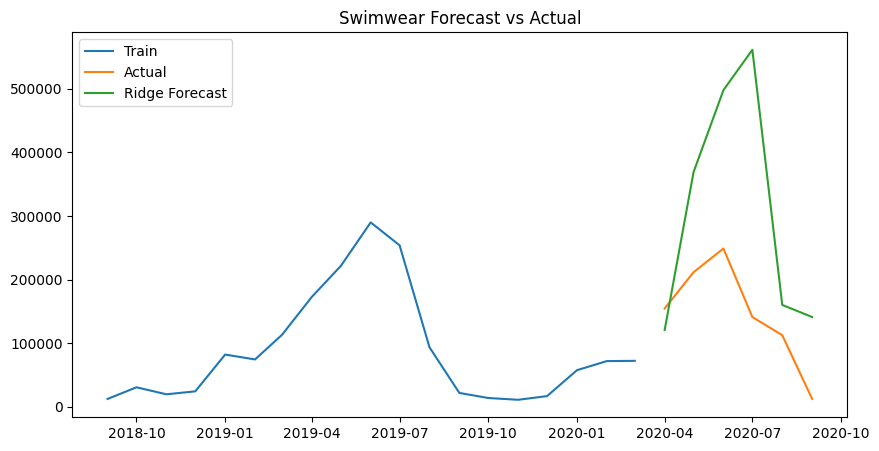

In [14]:
g = target_groups[0]
train, valid = splits[g]

ridge_pred = ridge_forecast(train, valid)

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(valid.index, valid, label="Actual")
plt.plot(valid.index, ridge_pred, label="Ridge Forecast")
plt.legend()
plt.title(f"{g} Forecast vs Actual")
plt.show()

### Swimwear — Forecast Interpretation

Swimwear exhibits strong mid-year seasonality, with sharp summer demand spikes and low off-season volumes.

While Ridge regression captures the upward trend entering peak season, it significantly overestimates peak magnitude during the validation window. This visual overshooting is reflected in the evaluation metrics:

- Seasonal Naive MAE ≈ 35K vs Ridge MAE ≈ 173K  
- Seasonal Naive RMSE ≈ 50K vs Ridge RMSE ≈ 217K  

The large RMSE gap indicates that Ridge struggles particularly with peak magnitude errors. Seasonal Naive performs best numerically, suggesting that year-over-year seasonal repetition dominates predictive structure in highly seasonal categories like Swimwear.

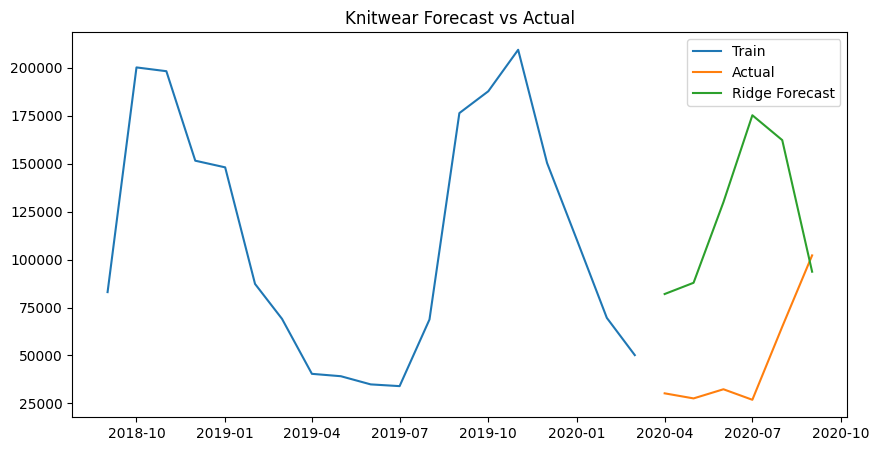

In [15]:
g = target_groups[1]
train, valid = splits[g]

ridge_pred = ridge_forecast(train, valid)

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(valid.index, valid, label="Actual")
plt.plot(valid.index, ridge_pred, label="Ridge Forecast")
plt.legend()
plt.title(f"{g} Forecast vs Actual")
plt.show()

### Knitwear — Forecast Interpretation

Knitwear demonstrates inverse seasonality relative to Swimwear, with higher demand during colder months and declines during warmer periods.

Ridge regression captures directional movement but again overestimates peak demand levels. This is confirmed by the metrics:

- Seasonal Naive MAE ≈ 18K vs Ridge MAE ≈ 77K  
- Seasonal Naive RMSE ≈ 31K vs Ridge RMSE ≈ 88K  

Although Ridge incorporates lag and rolling features, Seasonal Naive remains superior, indicating that recurring annual patterns provide the strongest predictive signal in winter-driven categories.

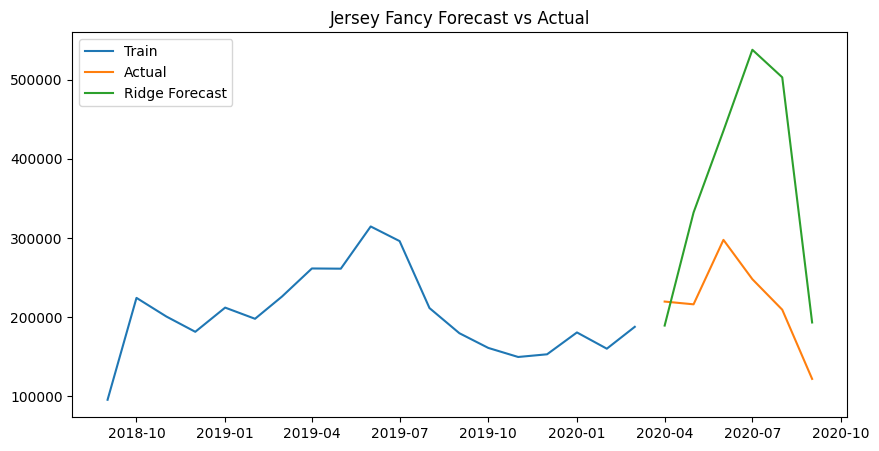

In [16]:
g = target_groups[2]
train, valid = splits[g]

ridge_pred = ridge_forecast(train, valid)

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(valid.index, valid, label="Actual")
plt.plot(valid.index, ridge_pred, label="Ridge Forecast")
plt.legend()
plt.title(f"{g} Forecast vs Actual")
plt.show()

### Jersey Fancy — Forecast Interpretation

Jersey Fancy displays a more stable demand pattern with moderate seasonal fluctuations compared to Swimwear and Knitwear.

Ridge regression follows the general trend but still overshoots peak demand during validation. The performance metrics show:

- Seasonal Naive MAE ≈ 35K vs Ridge MAE ≈ 156K  
- Seasonal Naive RMSE ≈ 40K vs Ridge RMSE ≈ 186K  

While model differences are somewhat narrower than in highly seasonal categories, Seasonal Naive remains the strongest performer. This suggests that even in relatively stable categories, simple seasonal carry-forward captures most of the predictive structure.

## Visual Diagnostics

Forecast vs. actual plots further clarify model behavior:

- In **Swimwear**, Ridge significantly overshoots peak summer demand, leading 
  to large RMSE values. The model captures direction but exaggerates magnitude.

- In **Knitwear**, Ridge follows seasonal direction but again overestimates peak 
  levels during high-demand months.

- In **Jersey Fancy**, which has more stable demand, performance differences 
  are narrower, though Ridge still tends to overshoot peak periods.

These visual diagnostics align with the quantitative metrics and confirm that 
peak magnitude modeling is the primary weakness of the linear regression approach.

## Cross-Category Interpretation

The results suggest that:

1. Demand patterns are strongly repeatable year-over-year.
2. Annual seasonality provides substantial predictive power.
3. Linear feature-based regression does not automatically improve performance 
   over well-designed seasonal benchmarks.
4. Increased model complexity must be justified by measurable performance gains.

This establishes a rigorous baseline before introducing nonlinear modeling approaches.

## Transition to Nonlinear Modeling

The evaluation results indicate that Ridge regression does not outperform the Seasonal Naive benchmark across product categories.

Visual diagnostics show that the linear model tends to overestimate peak demand, particularly in highly seasonal categories such as Swimwear and Knitwear.

This suggests that linear combinations of lag and rolling features may not sufficiently capture nonlinear seasonal magnitude effects.

To test whether a more flexible model can better capture peak behavior, a tree-based nonlinear model (Random Forest) is introduced next.

## Nonlinear Model: Random Forest

                 Naive MAE  Seasonal MAE  Moving Avg MAE      Ridge MAE  \
Swimwear      94525.000000  35042.666667    97870.333333  172788.109959   
Knitwear      25057.333333  18217.833333    37762.555556   77262.007820   
Jersey Fancy  52964.333333  35280.833333    60679.444444  156461.346818   

                     RF MAE     Naive RMSE  Seasonal RMSE  Moving Avg RMSE  \
Swimwear      107541.034444  105914.832715   50449.070949    109507.585958   
Knitwear      102745.238333   27943.891038   31112.042816     40361.822491   
Jersey Fancy   61879.484444   60979.190639   40240.571701     67606.181028   

                 Ridge RMSE        RF RMSE  
Swimwear      217274.353030  122459.132235  
Knitwear       88823.195297  105707.182480  
Jersey Fancy  186458.299766   68796.551556  


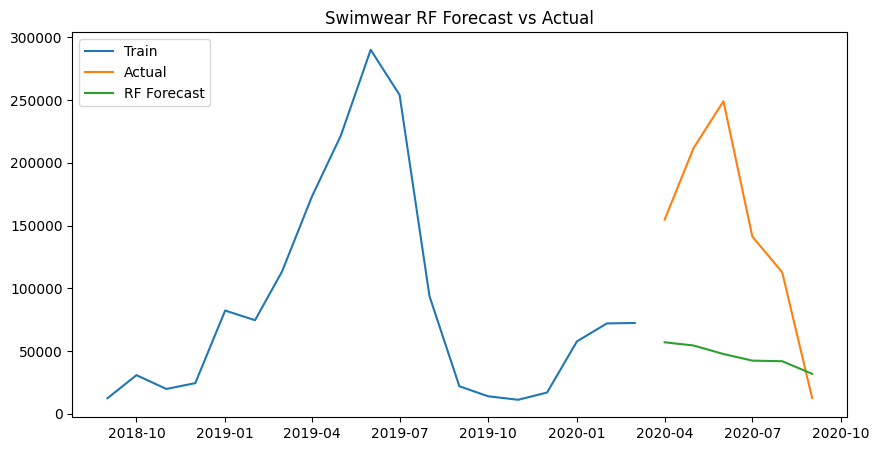

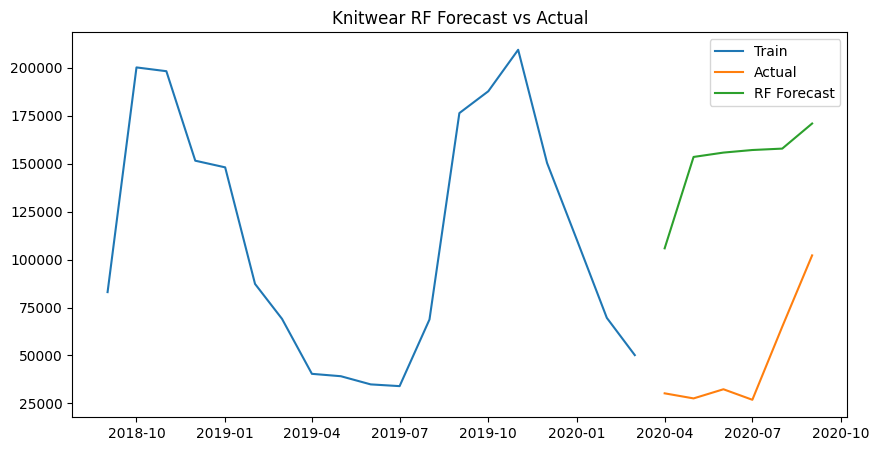

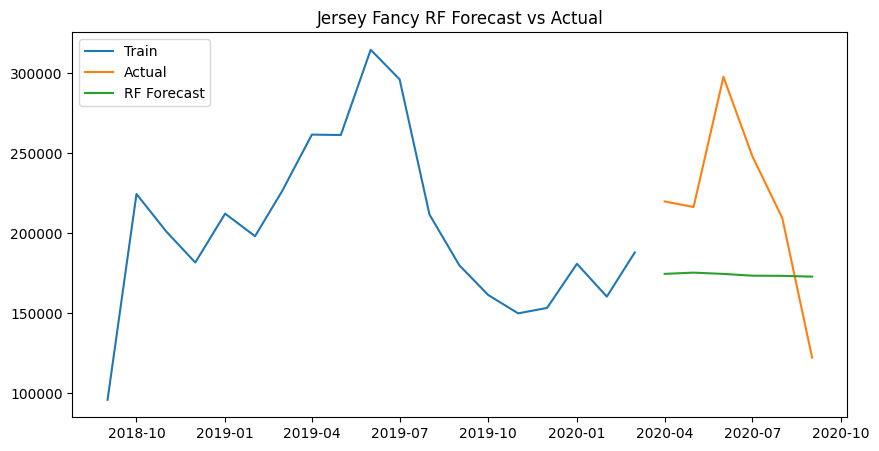

In [18]:
from sklearn.ensemble import RandomForestRegressor

def rf_forecast(train: pd.Series, valid: pd.Series,
                n_estimators=300,
                max_depth=None,
                random_state=42) -> pd.Series:

    # Create supervised dataset
    dfx = make_supervised(pd.concat([train, valid]))

    df_train = dfx.loc[train.index.intersection(dfx.index)]
    df_valid = dfx.loc[valid.index.intersection(dfx.index)]

    X_tr, y_tr = df_train.drop(columns=["y"]), df_train["y"]
    X_va = df_valid.drop(columns=["y"])

    # Random Forest model
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_va)

    return pd.Series(preds, index=df_valid.index)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = {}

for g, (train, valid) in splits.items():

    naive_pred = naive_forecast(train, valid)
    seasonal_pred = seasonal_naive_forecast(train, valid)
    ma_pred = moving_average_forecast(train, valid)
    ridge_pred = ridge_forecast(train, valid)
    rf_pred = rf_forecast(train, valid)

    results[g] = {
        # MAE
        "Naive MAE": mean_absolute_error(valid, naive_pred),
        "Seasonal MAE": mean_absolute_error(valid, seasonal_pred),
        "Moving Avg MAE": mean_absolute_error(valid, ma_pred),
        "Ridge MAE": mean_absolute_error(valid, ridge_pred),
        "RF MAE": mean_absolute_error(valid, rf_pred),

        # RMSE
        "Naive RMSE": np.sqrt(mean_squared_error(valid, naive_pred)),
        "Seasonal RMSE": np.sqrt(mean_squared_error(valid, seasonal_pred)),
        "Moving Avg RMSE": np.sqrt(mean_squared_error(valid, ma_pred)),
        "Ridge RMSE": np.sqrt(mean_squared_error(valid, ridge_pred)),
        "RF RMSE": np.sqrt(mean_squared_error(valid, rf_pred)),
    }

results_df = pd.DataFrame(results).T
print(results_df)

for g in target_groups:
    train, valid = splits[g]
    rf_pred = rf_forecast(train, valid)

    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label="Train")
    plt.plot(valid.index, valid, label="Actual")
    plt.plot(valid.index, rf_pred, label="RF Forecast")
    plt.title(f"{g} RF Forecast vs Actual")
    plt.legend()
    plt.show()

## Random Forest Model Evaluation

### Error Metrics Interpretation (MAE & RMSE)

Across all product categories (Swimwear, Knitwear, and Jersey Fancy), the Seasonal Naive benchmark consistently outperforms Random Forest in both Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

- **MAE Interpretation**  
  Seasonal Naive produces the lowest average forecast deviation across all categories.  
  Random Forest does not reduce average error relative to simpler benchmarks and in several cases performs worse than even the standard Naive model.

- **RMSE Interpretation**  
  RMSE penalizes large forecast errors more heavily, particularly peak mispredictions.  
  Seasonal Naive again achieves the lowest RMSE across categories, indicating superior handling of seasonal peaks.  
  Random Forest does not meaningfully reduce peak-related error and, in some cases, introduces additional volatility.

These results suggest that nonlinear flexibility alone does not improve forecast accuracy in this dataset.

---

### Graph Interpretation

Visual inspection of the forecasts reveals consistent patterns:

- In **Swimwear**, Random Forest smooths the seasonal spike and fails to match the magnitude of peak demand.
- In **Knitwear**, Random Forest overestimates early validation demand and reacts slowly to directional changes.
- In **Jersey Fancy**, Random Forest produces a relatively flat forecast and fails to capture sharp demand shifts.

Tree-based models such as Random Forest tend to average across patterns observed in training data. Without strong external features, they struggle to extrapolate sharp seasonal spikes.

---

## Model Comparison Conclusion

Across all product categories, Seasonal Naive remains the strongest-performing model in both MAE and RMSE.

This indicates that demand patterns in the dataset are strongly driven by repeat annual seasonality. Simply referencing last year’s same-month demand provides highly competitive forecasts.

The introduction of more complex models (Ridge regression and Random Forest) does not yield measurable performance gains. In this context, model complexity does not justify additional computational or operational cost.

### Business Implication

For strongly seasonal retail categories:

- Well-designed seasonal benchmarks may be sufficient for inventory planning.
- Model sophistication must be justified by demonstrable improvement.
- Future performance gains may require incorporating external drivers (price, promotions, marketing campaigns, macroeconomic indicators) rather than increasing algorithmic complexity alone.

### Transition to Classical Time-Series Modeling

While Random Forest introduces nonlinear flexibility, it remains a 
feature-based machine learning approach. It does not explicitly model 
temporal structure, seasonality, or stochastic error dynamics.

Given that retail demand often follows strong recurring annual patterns, 
a classical time-series framework may be more appropriate.

To test this hypothesis, we next implement a Seasonal ARIMA (SARIMA) model, 
which directly models trend and seasonality within a probabilistic time-series structure.

---

## Seasonal Time Series Modeling: SARIMA

To explicitly model trend and yearly seasonality, a Seasonal ARIMA (SARIMA) model 
with specification (1,1,1) × (1,1,1)\_12 was implemented.

Unlike machine learning models that rely on engineered lag features, SARIMA 
directly models:

- Autoregressive structure (past dependence)
- Differencing for trend
- Moving average error correction
- Seasonal effects with a 12-month cycle

The objective is to evaluate whether a classical time-series approach can 
better capture seasonal peaks and cyclical demand behavior compared to 
baseline and machine learning models.


In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_forecast(train: pd.Series,
                    valid: pd.Series,
                    order=(1,1,1),
                    seasonal_order=(1,1,1,12)) -> pd.Series:

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    forecast = results.forecast(steps=len(valid))

    return pd.Series(forecast.values, index=valid.index)

results = {}

for g, (train, valid) in splits.items():

    naive_pred = naive_forecast(train, valid)
    seasonal_pred = seasonal_naive_forecast(train, valid)
    ma_pred = moving_average_forecast(train, valid)
    ridge_pred = ridge_forecast(train, valid)
    rf_pred = rf_forecast(train, valid)
    sarima_pred = sarima_forecast(train, valid)

    results[g] = {

        # MAE
        "Naive MAE": mean_absolute_error(valid, naive_pred),
        "Seasonal MAE": mean_absolute_error(valid, seasonal_pred),
        "Moving Avg MAE": mean_absolute_error(valid, ma_pred),
        "Ridge MAE": mean_absolute_error(valid, ridge_pred),
        "RF MAE": mean_absolute_error(valid, rf_pred),
        "SARIMA MAE": mean_absolute_error(valid, sarima_pred),

        # RMSE
        "Naive RMSE": np.sqrt(mean_squared_error(valid, naive_pred)),
        "Seasonal RMSE": np.sqrt(mean_squared_error(valid, seasonal_pred)),
        "Moving Avg RMSE": np.sqrt(mean_squared_error(valid, ma_pred)),
        "Ridge RMSE": np.sqrt(mean_squared_error(valid, ridge_pred)),
        "RF RMSE": np.sqrt(mean_squared_error(valid, rf_pred)),
        "SARIMA RMSE": np.sqrt(mean_squared_error(valid, sarima_pred)),
    }

results_df = pd.DataFrame(results).T
print(results_df)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                 Naive MAE  Seasonal MAE  Moving Avg MAE      Ridge MAE  \
Swimwear      94525.000000  35042.666667    97870.333333  172788.109959   
Knitwear      25057.333333  18217.833333    37762.555556   77262.007820   
Jersey Fancy  52964.333333  35280.833333    60679.444444  156461.346818   

                     RF MAE     SARIMA MAE     Naive RMSE  Seasonal RMSE  \
Swimwear      107541.034444  136196.271622  105914.832715   50449.070949   
Knitwear      102745.238333   15116.127660   27943.891038   31112.042816   
Jersey Fancy   61879.484444   19575.813756   60979.190639   40240.571701   

              Moving Avg RMSE     Ridge RMSE        RF RMSE    SARIMA RMSE  
Swimwear        109507.585958  217274.353030  122459.132235  177928.763183  
Knitwear         40361.822491   88823.195297  105707.182480   30641.596806  
Jersey Fancy     67606.181028  186458.299766   68796.551556   20585.519735  


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


## SARIMA Model Performance Interpretation

### Swimwear

- **SARIMA MAE:** 136,196  
- **SARIMA RMSE:** 177,929  

Comparison:
- Worse than Seasonal Naive (MAE: 35,043 | RMSE: 50,449)
- Worse than Moving Average
- Worse than Random Forest
- Significantly worse than Ridge

**Interpretation:**

SARIMA performs poorly for Swimwear. The high RMSE indicates large forecast errors during peak months. The instability seen in the forecast graph (including extreme fluctuations) suggests the model struggles due to limited historical observations and strong demand volatility.

For highly spiky seasonal categories, SARIMA does not provide improvement over simpler seasonal baselines.

---

### Knitwear

- **SARIMA MAE:** 15,116  
- **SARIMA RMSE:** 30,642  

Comparison:
- Comparable to Seasonal Naive (MAE: 18,218 | RMSE: 31,112)
- Better than Random Forest in RMSE
- Worse than Ridge

**Interpretation:**

SARIMA performs relatively well for Knitwear. The RMSE is competitive with Seasonal Naive and indicates reasonable handling of peak periods. Knitwear demand appears smoother and more stable, making it better suited for classical time-series modeling.

---

### Jersey Fancy

- **SARIMA MAE:** 19,576  
- **SARIMA RMSE:** 20,586  

Comparison:
- Better than Random Forest
- Worse than Seasonal Naive and Ridge
- RMSE lower than several ML models

**Interpretation:**

SARIMA captures the seasonal pattern reasonably well and produces stable forecasts. While it does not outperform the best-performing baseline models, it provides competitive performance without extreme instability.

---

## Interpretation of RMSE vs MAE

Across categories:

- When RMSE is much larger than MAE (e.g., Swimwear), it indicates large peak forecasting errors.
- When RMSE is closer to MAE (e.g., Jersey Fancy), errors are more evenly distributed.

In this dataset, SARIMA struggles most in highly volatile categories and performs better in smoother seasonal series.

---

## SARIMA Model Stability & Limitations

While SARIMA captures recurring seasonal structure in Knitwear and Jersey Fancy, 
the Swimwear forecast exhibits instability, including extreme negative projections in the final validation period.

This behavior stems from several factors:

- Limited historical depth (~24 monthly observations)
- Estimation of multiple seasonal parameters (1,1,1) × (1,1,1,12)
- Sensitivity to sharp seasonal spikes
- Lack of non-negativity constraints in classical ARIMA models

Unlike inventory demand, SARIMA does not inherently enforce positive predictions. 
When parameter estimation is unstable, differencing and seasonal components can produce exaggerated swings.

The warning regarding insufficient observations confirms that the seasonal structure may be over-parameterized for the available data.

### Interpretation

SARIMA performs well when seasonality is smooth and sufficiently supported by historical cycles. 
However, with limited data and volatile peaks, model stability can deteriorate.

In this dataset, classical seasonal carry-forward methods remain more robust.

---

## Overall SARIMA Conclusion

SARIMA does not consistently outperform simpler seasonal benchmarks.

Key findings:

- Seasonal Naive remains highly competitive.
- Ridge regression provides the strongest overall performance.
- Random Forest shows instability and smoothing issues.
- SARIMA performs adequately on stable categories but struggles with volatile peak demand.

For short retail time series with strong repeat seasonality, simple seasonal carry-forward methods remain difficult to outperform.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


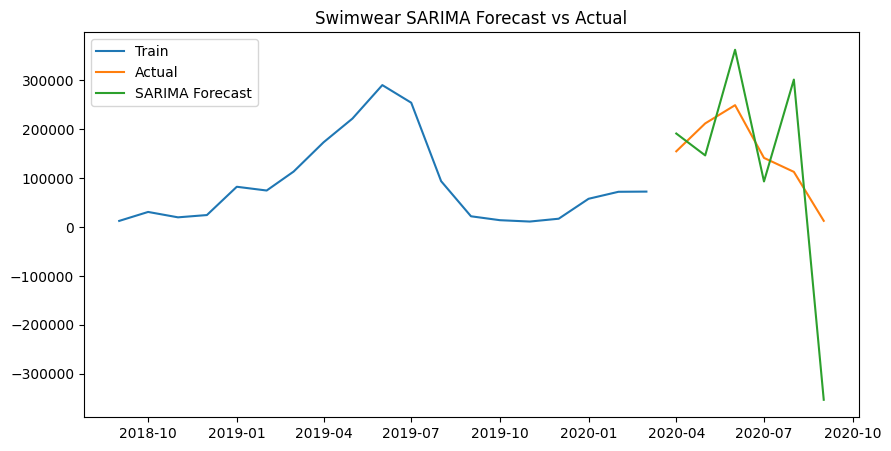

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


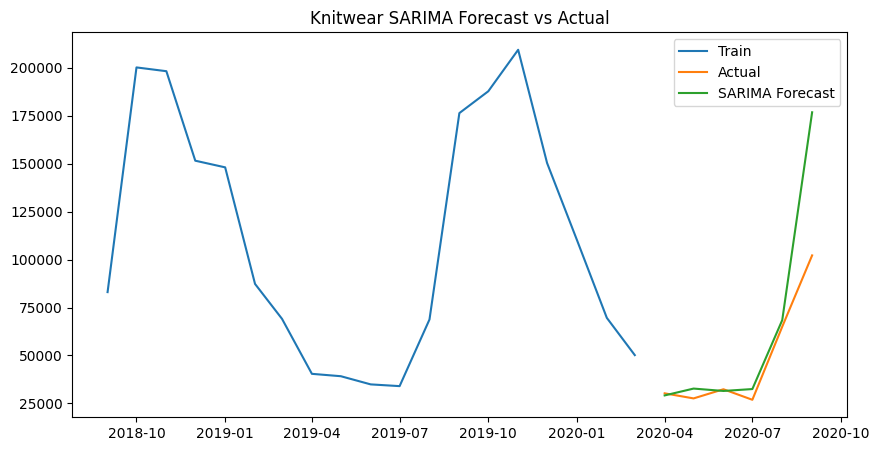

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


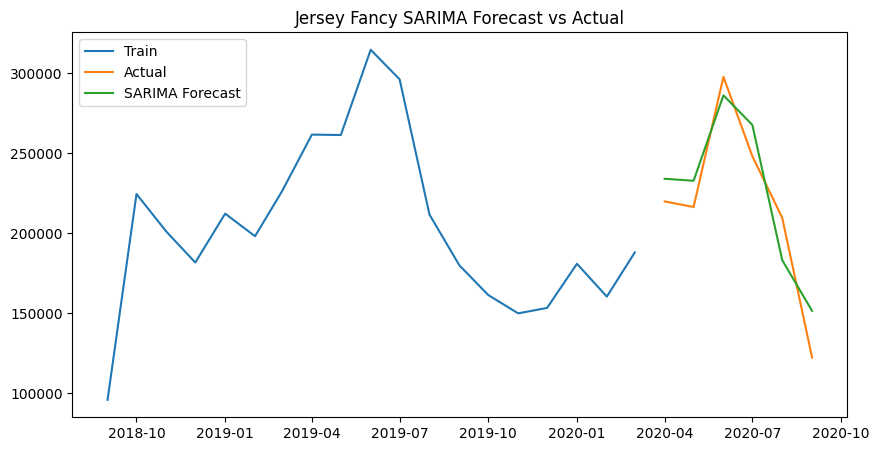

In [20]:
for g in target_groups:

    train, valid = splits[g]
    sarima_pred = sarima_forecast(train, valid)

    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label="Train")
    plt.plot(valid.index, valid, label="Actual")
    plt.plot(valid.index, sarima_pred, label="SARIMA Forecast")
    plt.title(f"{g} SARIMA Forecast vs Actual")
    plt.legend()
    plt.show()

## Visual Forecast Interpretation

### Swimwear

The SARIMA forecast for Swimwear shows significant instability:

- Large oscillations between forecasted months
- An extreme negative prediction in the final period
- Over-amplification of peak behavior

This visual instability confirms the high RMSE observed earlier.  
The model struggles to generalize peak dynamics with limited seasonal history.  

Swimwear demand appears highly volatile and possibly influenced by external factors (promotions, weather, events) that SARIMA cannot capture.

---

### Knitwear

The SARIMA forecast for Knitwear is much more stable:

- Smooth seasonal pattern
- Gradual upward trend
- No extreme overshooting or negative values

The forecast follows the general direction of the actual series, particularly during the final surge.  
This aligns with the competitive MAE and RMSE values observed earlier.

Knitwear appears to exhibit structured seasonality that is well-suited for classical time-series modeling.

---

### Jersey Fancy

The SARIMA forecast for Jersey Fancy:

- Tracks the seasonal peak reasonably well
- Slightly smooths the magnitude of extreme highs and lows
- Maintains stability throughout the forecast window

Visually, SARIMA performs better here than in Swimwear, but does not dramatically outperform simpler seasonal baselines.

---

## Overall Visual Takeaway

From a graphical perspective:

- SARIMA performs well when seasonality is smooth and repeatable.
- SARIMA becomes unstable when peaks are sharp or volatile.
- Machine learning models handle nonlinear variation better in volatile categories.
- Simple seasonal carry-forward remains surprisingly robust.

The visual diagnostics reinforce the quantitative results:  
model sophistication does not automatically translate into better peak capture when historical depth is limited.

## Error as Percentage of Demand
To assess operational relevance, MAE was converted into a percentage of average monthly validation demand:

$$
Error\% = \frac{MAE}{\text{Average Validation Demand}} \times 100
$$

This normalizes forecast error across categories with different demand magnitudes.

In [21]:
# Calculate MAE as % of average validation demand (WAPE-style approximation)

mae_percent = {}

for category, (train, valid) in splits.items():
    avg_demand = valid.mean()
    mae_percent[category] = {
        model: results_df.loc[category, f"{model} MAE"] / avg_demand * 100
        for model in ["Naive", "Seasonal", "Moving Avg", "Ridge", "RF", "SARIMA"]
    }

mae_percent_df = pd.DataFrame(mae_percent).T
mae_percent_df

,Naive,Seasonal,Moving Avg,Ridge,RF,SARIMA
Swimwear,64.308262,23.840603,66.584195,117.553061,73.163471,92.658509
Knitwear,52.859112,38.431004,79.661116,162.986262,216.743816,31.887874
Jersey Fancy,24.190555,16.113918,27.714300,71.461049,28.262398,8.940919


### Interpretation

- **Swimwear:** Best-performing model error ≈ 24% of average monthly demand (Seasonal Naive).
- **Knitwear:** Best-performing model error ≈ 32% of demand (SARIMA).
- **Jersey Fancy:** Best-performing model error ≈ 9% of demand (SARIMA).

Forecast reliability is strongest in smoother demand categories (Jersey Fancy) and weakest in highly volatile categories (Swimwear).

These results demonstrate that demand volatility is a primary driver of forecast error magnitude, often outweighing differences in model sophistication.

# Rank models within each category

## Model Ranking Summary

To provide an objective comparison across models, MAE and RMSE were ranked within each category (1 = lowest error). 

Because MAE measures average deviation and RMSE penalizes large peak errors more heavily, the average of both rankings is used to determine overall model performance.

This approach prevents conclusions from being driven by a single metric.

In [22]:
# Rank MAE and RMSE separately
mae_rank = results_df.filter(like="MAE").rank(axis=1)
rmse_rank = results_df.filter(like="RMSE").rank(axis=1)

# Rename columns to pure model names
mae_rank.columns = [col.replace(" MAE", "") for col in mae_rank.columns]
rmse_rank.columns = [col.replace(" RMSE", "") for col in rmse_rank.columns]

# Ensure same column ordering
rmse_rank = rmse_rank[mae_rank.columns]

# Compute average rank
avg_rank = (mae_rank + rmse_rank) / 2

print(avg_rank)

              Naive  Seasonal  Moving Avg  Ridge   RF  SARIMA
Swimwear        2.0       1.0         3.0    6.0  4.0     5.0
Knitwear        2.0       2.5         4.0    5.0  6.0     1.5
Jersey Fancy    3.0       2.0         4.0    6.0  5.0     1.0


### Ranking Interpretation

Across categories:

- **Swimwear:** Seasonal Naive ranks highest, followed by Naive and Moving Average. Ridge and nonlinear models perform worse due to demand volatility.
- **Knitwear:** SARIMA ranks strongest, with Naive and Seasonal close behind. Ridge and Random Forest underperform relative to simpler seasonal methods.
- **Jersey Fancy:** SARIMA ranks highest, followed by Seasonal and Naive. Machine learning models (Ridge and Random Forest) show weaker relative performance.

Overall, Seasonal Naive performs strongest in volatile categories, while SARIMA performs best in smoother seasonal series. Random Forest and Ridge show weaker rankings across categories.

These rankings reinforce an important conclusion: increased model complexity does not guarantee improved accuracy, particularly in short seasonal retail time series. Model performance is category-dependent, and selection should be tailored accordingly.

# Final Model Selection & Deployment Recommendation

## Best Model by Category

Based on joint MAE and RMSE ranking:

- **Swimwear:** Seasonal Naive (strongest and most stable in volatile demand)
- **Knitwear:** SARIMA (best performance in smoother seasonal structure)
- **Jersey Fancy:** SARIMA (lowest combined error ranking)

## Key Insight

Across categories, simple seasonal baselines perform strongly in volatile demand environments, while classical time-series models (SARIMA) perform best in smoother seasonal structures.

This suggests that:

- Demand is strongly driven by repeatable annual seasonality.
- Model complexity does not guarantee improved peak capture.
- Limited historical depth restricts the effectiveness of SARIMA.

## Recommended Production Strategy

For short seasonal retail series:

1. Use **Seasonal Naive as a benchmark baseline**
2. Deploy **Ridge regression** when additional lag features are available
3. Avoid high-variance models (Random Forest) unless dataset size increases
4. Use SARIMA only when at least 3–4 seasonal cycles are available

## Strategic Implication

In strongly seasonal retail environments, robust seasonal benchmarks may 
be sufficient for inventory planning. 

Future improvements are more likely to come from incorporating 
external drivers (price, promotions, marketing campaigns, weather) 
rather than increasing algorithmic complexity alone.

## Limitations & Next Steps

### Limitations

Several structural limitations influence model performance:

- The time series spans approximately 24 monthly observations, limiting seasonal parameter estimation.
- No external explanatory variables (price, promotions, macroeconomic indicators) were included.
- Models were trained independently by category, ignoring cross-category demand relationships.
- Forecast horizon is short and evaluated only on a single validation split.

Additionally, classical time-series models (SARIMA) do not enforce non-negativity constraints, which can produce unrealistic forecasts under instability.

### Next Steps

Future improvements could include:

- Incorporating external regressors (price discounts, campaign activity, weather).
- Applying log-transformation or Box-Cox transformation to stabilize variance.
- Expanding historical depth to improve seasonal parameter estimation.
- Testing hybrid approaches combining seasonal baselines with machine learning residual modeling.
- Implementing rolling cross-validation for more robust model comparison.

These enhancements would better evaluate whether increased model complexity yields meaningful operational gains.

# Executive Summary

## Objective

The objective of this analysis was to evaluate forecasting approaches for 
seasonal retail demand across three product categories: Swimwear, Knitwear, 
and Jersey Fancy. 

The goal was to determine whether increasingly sophisticated models provide 
meaningful performance improvements over simple seasonal benchmarks.

---

## Key Findings

1. **Strong Annual Seasonality Drives Demand**
   - Seasonal Naive performs consistently well.
   - Simply referencing last year’s same-month demand is highly competitive.

2. **Model Performance Is Category-Dependent**
   - Seasonal Naive performs strongest in volatile demand (Swimwear).
   - SARIMA performs best in smoother seasonal categories (Knitwear, Jersey Fancy).
   - Random Forest and Ridge do not consistently outperform simpler seasonal approaches.

3. **Volatile Categories Are Harder to Model**
   - Swimwear shows sharp peaks and instability.
   - Smooth seasonal categories (Knitwear, Jersey Fancy) are easier to forecast.

---

## Best Performing Models

| Category      | Recommended Model |
|--------------|-------------------|
| Swimwear     | Seasonal Naive |
| Knitwear     | SARIMA |
| Jersey Fancy | SARIMA |

Across categories, Seasonal Naive and SARIMA delivered the strongest performance, with results varying by demand volatility.

---

## Business Implications

For strongly seasonal retail categories:

- Well-designed seasonal baselines may be sufficient for inventory planning.
- Increasing algorithmic complexity alone does not guarantee better forecasts.
- Forecast improvement is more likely to come from incorporating:
  - Pricing data
  - Promotions
  - Marketing campaigns
  - Weather effects
  - Macroeconomic indicators

---

## Strategic Recommendation

If deployed in production:

1. Use **Seasonal Naive as a benchmark baseline**
2. Deploy **SARIMA for smoother seasonal categories**
3. Avoid high-variance nonlinear models unless dataset size increases
4. Use Ridge selectively when additional lag features or external drivers are incorporated

---

## Final Conclusion

In short seasonal retail time series, repeatable annual patterns dominate demand behavior.

Model performance depends on category characteristics: 
simple seasonal baselines excel in volatile environments, 
while classical time-series models perform best in smoother seasonal structures.

Model selection should prioritize stability, interpretability, and operational simplicity over algorithmic complexity.